In [1]:
pip install pretty_midi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 48.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.0 MB/s eta 0:00:00
  Created wheel for pretty_midi: filename=pretty_midi-0.2.11-py3-none-any.whl size=5595886 sha256=a4fb6fea20efc4c4ce91e7cef001c8a8253f355c206df2ffc412ed68a06e7809
  Stored in directory: /root/.cache/pip/wheels/f4/ad/93/a7042fe12668827574927ade9deec7f29aad2a1001b1501882
Successfully built pretty_midi


In [2]:
!python3 -m pip install pyfluidsynth


In [3]:
!apt-get install -y fluidsynth


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core fluid-soundfont-gm gsettings-desktop-schemas libatk-bridge2.0-0
  libatk1.0-0 libatk1.0-data libatspi2.0-0 libdouble-conversion3 libevdev2
  libfluidsynth3 libgtk-3-0 libgtk-3-bin libgtk-3-common libgudev-1.0-0
  libinput-bin libinput10 libinstpatch-1.0-2 libmd4c0 libmtdev1 libqt5core5a
  libqt5dbus5 libqt5gui5 libqt5network5 libqt5svg5 libqt5widgets5
  librsvg2-common libwacom-bin libwacom-common libwacom9 libxcb-icccm4
  libxcb-image0 libxcb-keysyms1 libxcb-render-util0 libxcb-util1
  libxcb-xinerama0 libxcb-xinput0 libxcb-xkb1 libxcomposite1
  libxkbcommon-x11-0 libxtst6 qsynth qt5-gtk-platformtheme
  qttranslations5-l10n session-migration timgm6mb-soundfont
Suggested packages:
  fluid-soundfont-gs gvfs qt5-image-formats-plugins qtwayland5 jackd
The following NEW packages will be installed:
  at-spi2-core fluid-soundfont

In [4]:
pip install soundfile

In [5]:
import pretty_midi
import os
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
import fluidsynth
from IPython.display import Audio

In [6]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Now that your Google Drive is mounted, you can define the path to your subfolder. I will assume `AAI590_FinalProject` is directly under `MyDrive` for this example. If it's located elsewhere (e.g., under `Colab Notebooks`), you'll need to adjust the `subfolder_path` accordingly.

Based on your file list, there is a directory named `/content/drive/MyDrive/Colab Notebooks/MSAAI521_FinalProject/`. If `AAI590_FinalProject` was a typo and you meant `MSAAI521_FinalProject`, please adjust the `subfolder_path` variable below.

In [7]:
# Define the path to the subfolder
project_directory = '/content/drive/MyDrive/AAI590_FinalProject'

# Check if the directory exists
if os.path.exists(project_directory):
    print(f"Accessing: {project_directory}")
    # Change the current working directory to the subfolder
    os.chdir(project_directory)
    print(f"Current working directory: {os.getcwd()}")
    print("Contents of the subfolder:")
    # List the contents of the subfolder
    for item in os.listdir(project_directory):
        print(item)
else:
    print(f"The directory '{project_directory}' does not exist. Please check the path and try again.")
    print("You might have intended to access '/content/drive/MyDrive/Colab Notebooks/MSAAI521_FinalProject/' based on available files.")

Accessing: /content/drive/MyDrive/AAI590_FinalProject
Current working directory: /content/drive/MyDrive/AAI590_FinalProject
Contents of the subfolder:
590-Classical-music-midi
TestingSamples
ChunkSamples
.ipynb_checkpoints


In [8]:
from pathlib import Path

# Setting file system variables
midi_directory = f"{project_directory}/590-Classical-music-midi"
testing_directory = f"{project_directory}/TestingSamples"
chunks_directory = f"{project_directory}/ChunkSamples"


print("Project directory:", project_directory)
print("MIDI directory:", midi_directory)
print("Exists:", Path(midi_directory).exists())
print("Chunks directory:", chunks_directory)

Project directory: /content/drive/MyDrive/AAI590_FinalProject
MIDI directory: /content/drive/MyDrive/AAI590_FinalProject/590-Classical-music-midi
Exists: True
Chunks directory: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples


In [9]:
def load_midi_file(file_path: str, fs: int = 100) -> tuple[pretty_midi.PrettyMIDI | None, float | None, pretty_midi.TimeSignature | None, int]:
    """
    Loads a MIDI file from the given file path and returns its PrettyMIDI object,
    initial tempo, time signature, and the frames per second (fs) used for piano roll calculation.

    Args:
        file_path (str): The path to the MIDI file.
        fs (int): Frames per second to use for piano roll calculation (default: 100).

    Returns:
        tuple[pretty_midi.PrettyMIDI | None, float | None, pretty_midi.TimeSignature | None, int]:
            A tuple containing:
            - pretty_midi.PrettyMIDI object if successful, None otherwise.
            - Initial tempo of the MIDI file (float) if successful, None otherwise.
            - Initial time signature of the MIDI file (pretty_midi.TimeSignature) if successful, None otherwise.
            - Frames per second (fs) used for piano roll.
    """
    if not os.path.exists(file_path):
        print(f"Error: File not found at {file_path}")
        return None, None, None, fs # Return None for midi_data, tempo, and time_signature, but fs value

    try:
        midi_data = pretty_midi.PrettyMIDI(file_path)
        print(f"Successfully loaded MIDI file: {file_path}")

        tempo_times, tempos = midi_data.get_tempo_changes()
        print(f"Tempo changes loaded correctly")

        if(tempos.size > 0):
            print(f"Initial tempo: {tempos[0]}")
            initial_tempo = tempos[0]
        else:
            print(f"No tempo changes found in the MIDI file")
            initial_tempo = 120.0 # Default to 120 BPM if no tempo changes explicitly set
        #initial_tempo = tempos[0] if tempos else 120.0 # Default to 120 BPM if no tempo changes explicitly set
        print(f"Initial tempo selected correctly")

        initial_time_signature = midi_data.time_signature_changes[0] if midi_data.time_signature_changes else None
        print(f"Initial time signature loaded correctly")

        return midi_data, initial_tempo, initial_time_signature, fs
    except Exception as e:
        print(f"Error loading MIDI file {file_path}: {e}")
        return None, None, None, fs # Return None for midi_data, tempo, and time_signature, but fs value

In [10]:
def split_midi_by_measure(pm_data: pretty_midi.PrettyMIDI) -> list[pretty_midi.PrettyMIDI]:
    """
    Splits a PrettyMIDI object into a list of PrettyMIDI objects, one for each measure.
    Notes are adjusted to have start/end times relative to the beginning of their measure.

    Args:
        pm_data (pretty_midi.PrettyMIDI): The PrettyMIDI object to split.

    Returns:
        list[pretty_midi.PrettyMIDI]: A list of PrettyMIDI objects, each representing a measure.
    """
    measures = []
    downbeats = pm_data.get_downbeats()

    if not downbeats:
        print("No downbeats found. Returning original MIDI as a single measure.")
        return [pm_data]

    # Add an implicit end boundary if the last downbeat is not the very end of the piece
    end_time = max([note.end for instrument in pm_data.instruments for note in instrument.notes]) if pm_data.instruments else 0
    measure_boundaries = list(downbeats)
    if measure_boundaries[-1] < end_time:
        measure_boundaries.append(end_time)

    for i in range(len(measure_boundaries) - 1):
        measure_start_time = measure_boundaries[i]
        measure_end_time = measure_boundaries[i+1]

        # Create a new PrettyMIDI object for this measure
        measure_pm = pretty_midi.PrettyMIDI(resolution=pm_data.resolution)

        # Copy time signature and tempo map for the current measure if they fall within its bounds
        # This simplified approach assumes the first relevant time signature/tempo is representative.
        # A more robust solution would track changes throughout the measure.
        for ts in pm_data.time_signature_changes:
            if measure_start_time <= ts.time < measure_end_time:
                measure_pm.time_signature_changes.append(pretty_midi.TimeSignature(ts.numerator, ts.denominator, 0)) # Set time to 0 for relative measure start
                break # Assuming one time signature per measure for simplicity
        if not measure_pm.time_signature_changes and pm_data.time_signature_changes:
             # If no explicit TS found in bounds, use the last one before measure start
             relevant_ts = [ts for ts in pm_data.time_signature_changes if ts.time <= measure_start_time]
             if relevant_ts:
                 last_ts = relevant_ts[-1]
                 measure_pm.time_signature_changes.append(pretty_midi.TimeSignature(last_ts.numerator, last_ts.denominator, 0))
             else:
                measure_pm.time_signature_changes.append(pretty_midi.TimeSignature(4, 4, 0)) # Default if nothing found
        elif not measure_pm.time_signature_changes:
            measure_pm.time_signature_changes.append(pretty_midi.TimeSignature(4, 4, 0)) # Default if no TS in original MIDI

        # Iterate through instruments and notes
        for original_instrument in pm_data.instruments:
            new_instrument = pretty_midi.Instrument(program=original_instrument.program,
                                                    is_drum=original_instrument.is_drum,
                                                    name=original_instrument.name)
            for note in original_instrument.notes:
                # Check if the note is within the current measure's boundaries
                # A note is considered in the measure if its start time is within the measure,
                # or if it starts before and extends into the measure.
                if (measure_start_time <= note.start < measure_end_time) or \
                   (note.start < measure_start_time and note.end > measure_start_time):

                    # Adjust note start and end times relative to the measure's start
                    relative_start = max(0.0, note.start - measure_start_time)
                    relative_end = note.end - measure_start_time

                    # Ensure the note doesn't extend beyond the measure's relative end
                    relative_end = min(relative_end, measure_end_time - measure_start_time)

                    # Only add note if it has a positive duration within the measure
                    if relative_end > relative_start:
                        new_note = pretty_midi.Note(
                            velocity=note.velocity,
                            pitch=note.pitch,
                            start=relative_start,
                            end=relative_end
                        )
                        new_instrument.notes.append(new_note)
            if new_instrument.notes:
                measure_pm.instruments.append(new_instrument)

        measures.append(measure_pm)

    return measures

In [24]:
# Convert MIDI to audio wave file (required for MERT)
def midi_file_to_audio(midi_path, sr=24000):
    midi = pretty_midi.PrettyMIDI(midi_path)
    audio = midi.fluidsynth(fs=sr)
    return audio, sr
def midi_data_to_audio(midi_data, sr=24000):
    audio = midi_data.fluidsynth(fs=sr)
    return audio, sr
def save_audio(audio, sr, output_path):
    # Save the audio content to a WAV file
    sf.write(output_path, audio, sr)
    print(f"Audio saved to: {output_path}")
def create_midi_sequence_from_notes(notes, offset=0):
    """
    Creates a PrettyMIDI object from a list of note tuples.
    Each note tuple is expected to be (pitch, start, end, duration).
    """
    midi_sequence = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=0)  # Selecting Piano
    for note_array in notes:
        pitch, start, end, duration = note_array
        # Explicitly cast pitch to int, as numpy array might have cast it to float
        new_note = pretty_midi.Note(
            velocity=127,
            pitch=int(pitch),  # Ensure pitch is an integer
            start=start - offset,
            end=end - offset
        )
        instrument.notes.append(new_note)
    midi_sequence.instruments.append(instrument)
    return midi_sequence
def midi_to_note_sequence(midi_path):
    midi = pretty_midi.PrettyMIDI(midi_path)
    notes = []
    for instrument in midi.instruments:
        for note in instrument.notes:
            notes.append([
                int(note.pitch),  # Pitch must be int
                note.start,       # Keep as float for precise timing
                note.end,         # Keep as float for precise timing
                note.end - note.start # Duration (float)
            ])
    notes = sorted(notes, key=lambda x: x[1])
    return np.array(notes)
def chunk_notes(notes, chunk_size=32):
    chunks = []
    # Breaking into chunks with 50% overlap, so i will increment by chunk_size/2 each iteration
    chunk_iteration = int(chunk_size/2)
    for i in range(0, len(notes), chunk_iteration):
        chunk = notes[i:i+chunk_size]
        if len(chunk) == chunk_size:
            chunks.append(chunk)
    return chunks
def embed_chunks(chunks):
    embeddings = []
    for chunk in chunks:
        # simple numeric representation for MERT placeholder
        vec = chunk.flatten()
        embeddings.append(vec)
    return embeddings
def get_first_note_start_in_chunk(chunk):
    # Get all note start times
    note_start_times = [note[1] for note in chunk]
    # Get the first note time
    first_note_time = min(note_start_times)
    return first_note_time
def chunks_to_audio(chunks, output_wav_path):
    i = 1
    for chunk in chunks:
        tmp_output_path = output_wav_path.replace('.wav', f'_chunk_{i}.wav')
        #print(f'Preparing file {tmp_output_path}...')
        first_note_time = get_first_note_start_in_chunk(chunk)
        #print(f'First note time in chunk: {first_note_time}')
        midi_sequence = create_midi_sequence_from_notes(chunk, first_note_time)
        #print(f'Midi sequence for file {tmp_output_path}:')
        #print(midi_sequence)
        audio, sr = midi_data_to_audio(midi_sequence)
        save_audio(audio, sr, tmp_output_path)
        i += 1
    return i - 1
def create_chunks_from_midi(midi_path, sr=24000, chunk_size=32, audio_path=''):
    if(audio_path == ''):
        audio_path = midi_path
    wav_path = audio_path.replace('.mid', '.wav')
    notes = midi_to_note_sequence(midi_path)
    #print('Notes:')
    #print(notes)
    chunks = chunk_notes(notes, chunk_size)
    #print('Chunks')
    #print(chunks)
    chunk_file_count = chunks_to_audio(chunks, wav_path)
    print(f'Created {chunk_file_count} chunks from {midi_path}')

In [12]:
def get_frame_first_note(midi_content, fs):
  #Get all note start times
  note_start_times = [note.start for instrument in midi_content.instruments for note in instrument.notes]
  #Get the first note time
  first_note_time = min(note_start_times)
  #Calculate the frame in which the note shows up
  first_frame = int(first_note_time * fs)
  #Return the first frame
  return first_frame
def midi_to_pianoroll(midi_path):
  # Load MIDI
  midi_data, initial_tempo, initial_time_signature, piano_roll_fs = load_midi_file(midi_path)
  if midi_data is None:
      return None, None
  # Get first frame with a note
  first_active_frame = get_frame_first_note(midi_data, piano_roll_fs)

  # Full piano roll, shape: (128, time)
  piano_roll = midi_data.get_piano_roll(fs=piano_roll_fs)
  piano_roll = piano_roll / 127.0  # Normalize velocity
  piano_roll = piano_roll[:, first_active_frame:]  # Trim leading silence
  piano_roll = piano_roll.T  # Now shape: (time, 128)

  # Clip to valid MIDI range
  piano_roll = piano_roll[:, :128]

  return piano_roll, piano_roll_fs
def plot_piano_roll(midi_path, title="Piano Roll", save_path=None):
  #First we obtain the piano roll based on the path
  piano_roll, fs = midi_to_pianoroll(midi_path)
  time_steps = piano_roll.shape[0] #Getting timesteps
  duration = time_steps / fs #Calculating duration
  time_axis = np.linspace(0, duration, time_steps) #Preparing time axis dimension
  print(f'Time Steps: {time_steps}, Frames per Second: {fs}, Duration: {duration:.2f}s')
  #Next, we plot the Piano Roll
  plt.figure(figsize=(12, 6))
  plt.imshow(piano_roll.T, aspect='auto', origin='lower',
              extent=[0, duration, 0, piano_roll.shape[1]], cmap='gray_r')
  plt.xlabel('Time (s)')
  plt.ylabel('MIDI Note')
  plt.title(title)
  plt.tight_layout()

  if save_path:
      plt.savefig(save_path)
  else:
      plt.show()


In [13]:
# Assuming a MIDI file exists in the testing_directory
example_midi_path = os.path.join(testing_directory, 'MidiOutputs/Beethoven/Fur Elise_Full_K-Amin_T-variable_bothhands.mid')

# Call the function and capture the returned values
midi_data_obj, initial_tempo, initial_time_signature, piano_roll_fs = load_midi_file(example_midi_path, fs=100)

# Print the captured parameters
if midi_data_obj:
    print(f"\nMIDI Data Object: {midi_data_obj}")
    print(f"Initial Tempo: {initial_tempo} BPM")
    if initial_time_signature:
        print(f"Initial Time Signature: {initial_time_signature.numerator}/{initial_time_signature.denominator}")
    else:
        print("Initial Time Signature: Not found")
    print(f"Frames Per Second (fs) for Piano Roll: {piano_roll_fs}")
else:
    print("Failed to load MIDI file.")

Successfully loaded MIDI file: /content/drive/MyDrive/AAI590_FinalProject/TestingSamples/MidiOutputs/Beethoven/Fur Elise_Full_K-Amin_T-variable_bothhands.mid
Tempo changes loaded correctly
Initial tempo: 75.0
Initial tempo selected correctly
Initial time signature loaded correctly

MIDI Data Object: <pretty_midi.pretty_midi.PrettyMIDI object at 0x7c8914c9b530>
Initial Tempo: 75.0 BPM
Initial Time Signature: 3/8
Frames Per Second (fs) for Piano Roll: 100


/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Successfully loaded MIDI file: /content/drive/MyDrive/AAI590_FinalProject/590-Classical-music-midi/beeth/elise.mid
Tempo changes loaded correctly
Initial tempo: 69.17997516438892
Initial tempo selected correctly
Initial time signature loaded correctly
Time Steps: 16473, Frames per Second: 100, Duration: 164.73s


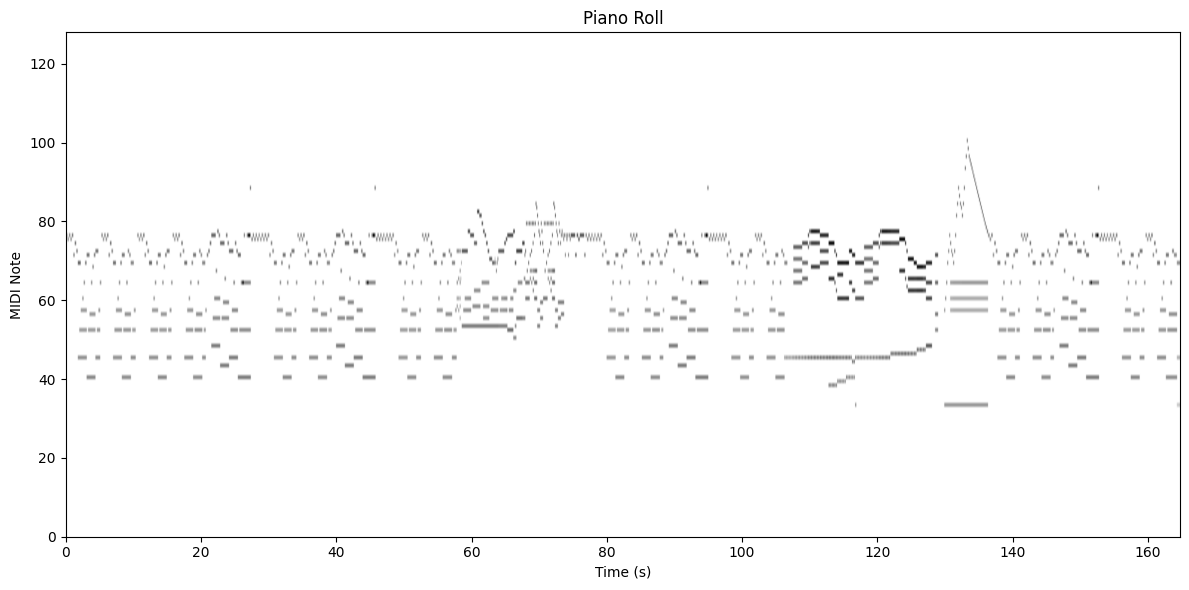

In [14]:
sample_path = f'{midi_directory}/beeth/elise.mid'
plot_piano_roll(sample_path)

Successfully loaded MIDI file: /content/drive/MyDrive/AAI590_FinalProject/TestingSamples/MidiOutputs/Beethoven/Fur Elise_Full_K-Amin_T-variable_bothhands.mid
Tempo changes loaded correctly
Initial tempo: 75.0
Initial tempo selected correctly
Initial time signature loaded correctly
Time Steps: 15691, Frames per Second: 100, Duration: 156.91s


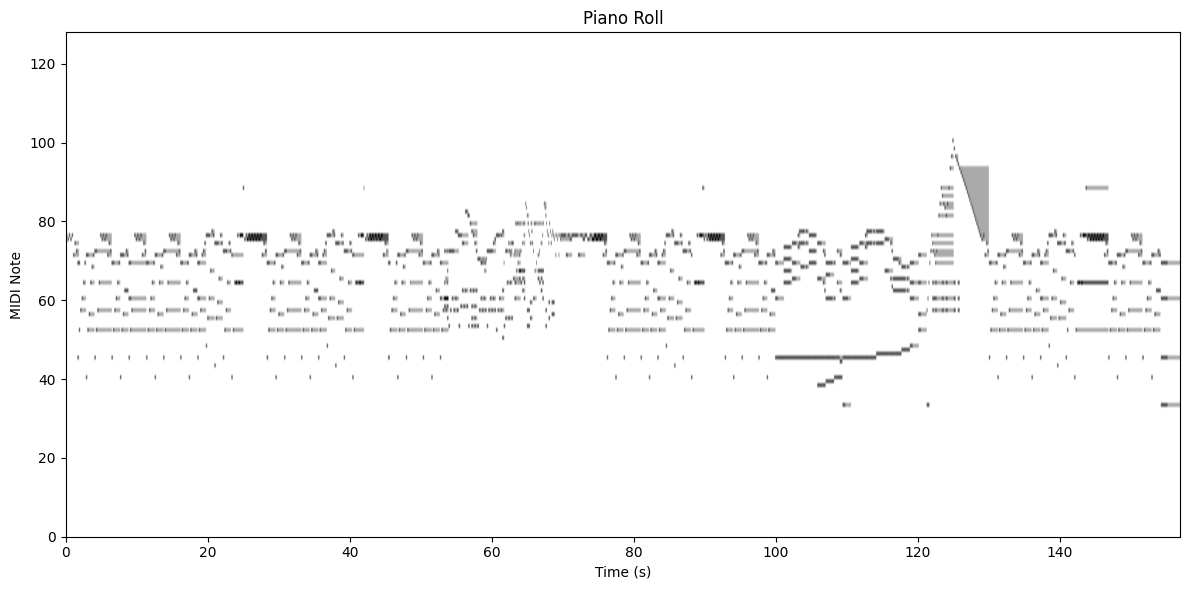

In [15]:
plot_piano_roll(example_midi_path)

In [28]:
import os
sample_file_name = os.path.basename(sample_path)

audio_path = f'{chunks_directory}/{Path(sample_file_name.replace('.mid','.wav'))}'

In [29]:
print(f'Sample_file_name: {sample_file_name}')
print(f'Audio Path: {audio_path}')


Sample_file_name: elise.mid
Audio Path: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise.wav


In [30]:
# Creating chunks and saving them into separate audio files
create_chunks_from_midi(sample_path, 24000, 32, audio_path)

Audio saved to: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_1.wav
Audio saved to: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_2.wav
Audio saved to: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_3.wav
Audio saved to: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_4.wav
Audio saved to: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_5.wav
Audio saved to: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_6.wav
Audio saved to: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_7.wav
Audio saved to: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_8.wav
Audio saved to: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_9.wav
Audio saved to: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_10.wav
Audio saved to: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_11.wav
Audio sa

In [32]:
import os
from pathlib import Path

# Ensure the base chunks directory exists
Path(chunks_directory).mkdir(parents=True, exist_ok=True)

print(f"Processing MIDI files from: {midi_directory}")
print(f"Saving audio chunks to: {chunks_directory}\n")

processed_midi_count = 0

for root, _, files in os.walk(midi_directory):
    for file in files:
        if file.endswith(('.mid', '.midi')):
            midi_file_path = os.path.join(root, file)

            # Construct the relative path from midi_directory
            relative_path = os.path.relpath(midi_file_path, midi_directory)

            # Create the corresponding output subdirectory within chunks_directory
            # The parent directory of the .wav file will be the new subfolder for the melody
            output_base_dir = os.path.join(chunks_directory, Path(relative_path).parent)
            Path(output_base_dir).mkdir(parents=True, exist_ok=True)

            # Construct the audio_path for the current MIDI file
            # This will be the base name for the WAV files (e.g., /path/to/chunks/melody_name/melody_name.wav)
            audio_path = os.path.join(output_base_dir, Path(file).stem)
            # although the chunk function will split it into melody_name_chunk_1.wav, melody_name_chunk_2.wav, etc...
            # The create_chunks_from_midi function will append _chunk_X.wav
            Path(audio_path).mkdir(parents=True, exist_ok=True)
            audio_file_name_base = Path(file).stem + '.wav'
            audio_path = os.path.join(audio_path, audio_file_name_base)

            print(f"\nProcessing: {midi_file_path}")
            print(f"Output audio base path: {audio_path}")

            try:
                create_chunks_from_midi(midi_file_path, sr=24000, chunk_size=32, audio_path=audio_path)
                processed_midi_count += 1
            except Exception as e:
                print(f"Error processing {midi_file_path}: {e}")

print(f"\nFinished processing {processed_midi_count} MIDI files.")

Streaming output truncated to the last 5000 lines.
Audio saved to: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/schubert/schubert_D850_2/schubert_D850_2_chunk_213.wav
Audio saved to: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/schubert/schubert_D850_2/schubert_D850_2_chunk_214.wav
Audio saved to: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/schubert/schubert_D850_2/schubert_D850_2_chunk_215.wav
Audio saved to: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/schubert/schubert_D850_2/schubert_D850_2_chunk_216.wav
Audio saved to: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/schubert/schubert_D850_2/schubert_D850_2_chunk_217.wav
Audio saved to: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/schubert/schubert_D850_2/schubert_D850_2_chunk_218.wav
Audio saved to: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/schubert/schubert_D850_2/schubert_D850_2_chunk_219.wav
Audio saved to: /content/drive/MyDrive/AAI590_FinalProject/C

In [ ]:
from transformers import AutoModel, AutoProcessor

# Load MERT model
model_name = "m-a-p/MERT-v1-95M"

processor = AutoProcessor.from_pretrained(
    model_name,
    trust_remote_code=True
)

model = AutoModel.from_pretrained(
    model_name,
    trust_remote_code=True
)

model.eval()

print("MERT model loaded successfully")

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

MERT model loaded successfully


In [ ]:
import torch

# Get a list of all .wav files in the chunks_directory
chunk_wav_files = [os.path.join(chunks_directory, f) for f in os.listdir(chunks_directory) if f.endswith('.wav')]

# Sort the files for consistent processing order
chunk_wav_files.sort()

print(f"Found {len(chunk_wav_files)} WAV chunk files in {chunks_directory}")

all_chunk_embeddings = []

for i, wav_file in enumerate(chunk_wav_files):
    print(f"Processing chunk {i+1}/{len(chunk_wav_files)}: {wav_file}")
    try:
        # Load the audio file
        audio_input, sampling_rate = sf.read(wav_file)

        # Process the audio to get features MERT expects
        inputs = processor(raw_speech=audio_input, sampling_rate=sampling_rate, return_tensors="pt")

        # Generate embeddings
        with torch.no_grad():
            outputs = model(**inputs)

        # The MERT model outputs a 'last_hidden_state' which are the embeddings
        # We can take the mean across the time dimension to get a single embedding per chunk
        chunk_embedding = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
        all_chunk_embeddings.append(chunk_embedding)
        print(f"  Generated embedding of shape: {chunk_embedding.shape}")

    except Exception as e:
        print(f"Error processing {wav_file}: {e}")

print("\nFinished generating embeddings for all chunks.")

# Convert list of embeddings to a numpy array for easier handling
if all_chunk_embeddings:
    all_chunk_embeddings_array = np.array(all_chunk_embeddings)
    print(f"Total embeddings array shape: {all_chunk_embeddings_array.shape}")
else:
    print("No embeddings were generated.")

Found 33 WAV chunk files in /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples
Processing chunk 1/33: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise.wav
  Generated embedding of shape: (768,)
Processing chunk 2/33: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_1.wav
  Generated embedding of shape: (768,)
Processing chunk 3/33: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_10.wav
  Generated embedding of shape: (768,)
Processing chunk 4/33: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_11.wav
  Generated embedding of shape: (768,)
Processing chunk 5/33: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_12.wav
  Generated embedding of shape: (768,)
Processing chunk 6/33: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_13.wav
  Generated embedding of shape: (768,)
Processing chunk 7/33: /content/drive/MyDrive/AAI590_FinalProject/ChunkSamples/elise_chunk_14.wav
  Gene

In [ ]:
all_chunk_embeddings_array

array([[-0.06526169, -0.08986434,  0.01106025, ..., -0.12569161,
         0.01292511,  0.15875973],
       [-0.05605015,  0.02903162,  0.1476077 , ...,  0.06878751,
        -0.12339675, -0.01053775],
       [-0.00215679,  0.06864046,  0.10211527, ...,  0.07713242,
        -0.158657  ,  0.07421888],
       ...,
       [-0.04903139,  0.0355635 ,  0.10422671, ...,  0.08874337,
        -0.03504748, -0.09810561],
       [-0.02771215, -0.02110263,  0.1903375 , ..., -0.0028037 ,
        -0.1456412 , -0.02211083],
       [-0.06512479,  0.02299381,  0.1268365 , ...,  0.04886309,
        -0.07233655, -0.11230969]], dtype=float32)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate the cosine similarity matrix
cosine_sim_matrix = cosine_similarity(all_chunk_embeddings_array)

print("Cosine Similarity Matrix shape:", cosine_sim_matrix.shape)
print("\nFirst 5x5 block of the Cosine Similarity Matrix:")
display(cosine_sim_matrix[:5, :5])

Cosine Similarity Matrix shape: (33, 33)

First 5x5 block of the Cosine Similarity Matrix:


array([[0.9999999 , 0.3274981 , 0.33961865, 0.33189514, 0.31973848],
       [0.3274981 , 1.0000002 , 0.9625899 , 0.92657423, 0.9624461 ],
       [0.33961865, 0.9625899 , 0.99999994, 0.96453846, 0.98271596],
       [0.33189514, 0.92657423, 0.96453846, 1.        , 0.96836454],
       [0.31973848, 0.9624461 , 0.98271596, 0.96836454, 0.9999998 ]],
      dtype=float32)

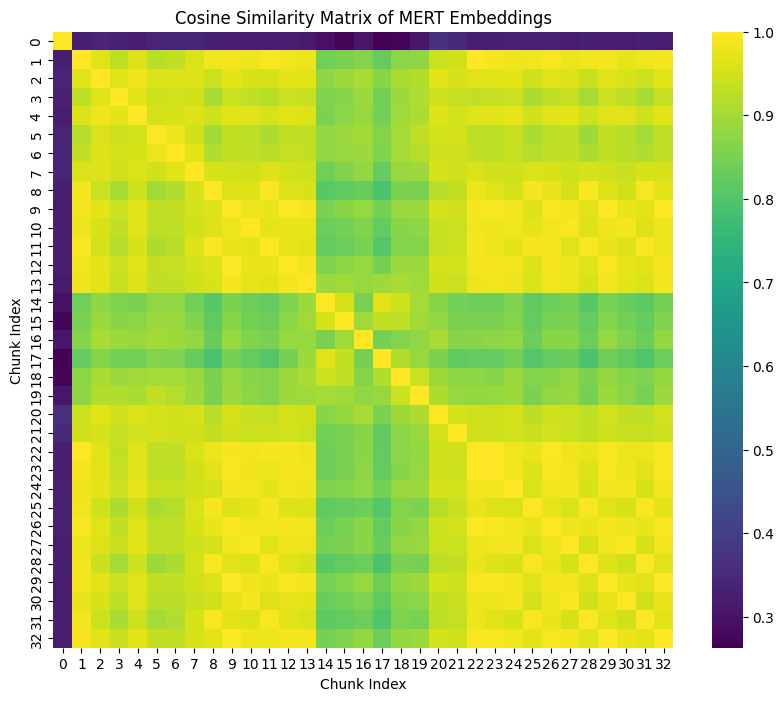

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(cosine_sim_matrix, annot=False, cmap='viridis', fmt=".2f", cbar=True)
plt.title('Cosine Similarity Matrix of MERT Embeddings')
plt.xlabel('Chunk Index')
plt.ylabel('Chunk Index')
plt.show()

The output `cosine_sim_matrix` is a square matrix where `cosine_sim_matrix[i, j]` represents the cosine similarity between the embedding of chunk `i` and chunk `j`. Values close to 1 indicate high similarity, while values close to -1 indicate high dissimilarity. The diagonal elements will always be 1, as an embedding is perfectly similar to itself.